In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

In [2]:
# Binary Classification using DNN on IMDB Dataset

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

# Load IMDB Dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.imdb.load_data(num_words=10000)

print("Training samples:", len(x_train))
print("Testing samples:", len(x_test))

# Pad sequences
max_length = 200

x_train = keras.preprocessing.sequence.pad_sequences(
    x_train,
    maxlen=max_length
)

x_test = keras.preprocessing.sequence.pad_sequences(
    x_test,
    maxlen=max_length
)

# Build DNN Model
model = keras.Sequential([

    layers.Embedding(
        input_dim=10000,
        output_dim=32,
        input_length=max_length
    ),

    layers.Flatten(),

    layers.Dense(64, activation='relu'),

    layers.Dense(32, activation='relu'),

    layers.Dense(1, activation='sigmoid')
])

# Compile Model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Model Summary
model.summary()

# Train Model
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.2
)

# Evaluate Model
loss, accuracy = model.evaluate(x_test, y_test)

print("\nTest Accuracy:", accuracy)

# Predictions
predictions = model.predict(x_test)

predicted_labels = (predictions > 0.5).astype("int32")

print("\nSample Predictions:")
print(predicted_labels[:10])

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples: 25000
Testing samples: 25000


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - accuracy: 0.7130 - loss: 0.5137 - val_accuracy: 0.8458 - val_loss: 0.3439
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.9384 - loss: 0.1678 - val_accuracy: 0.8526 - val_loss: 0.3651
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.9919 - loss: 0.0311 - val_accuracy: 0.8508 - val_loss: 0.4865
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.9985 - loss: 0.0065 - val_accuracy: 0.8478 - val_loss: 0.5628
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 1.0000 - loss: 8.3234e-04 - val_accuracy: 0.8456 - val_loss: 0.6188
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8442 - loss: 0.6359

Test Accuracy: 0.8442400097846985
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step

Sample Predictions:
[[0]
 [1]
 [1]
 [0]
 [1]
 [1]
 [1]
 [0]
 [1]
 [1]]


In [3]:
# Predict on test data
predictions = model.predict(x_test)

# Convert probabilities into 0 or 1
predicted_labels = (predictions > 0.5).astype("int32")

# Print first 10 predictions
for i in range(10):
    print("Predicted:", predicted_labels[i][0],
          "Actual:", y_test[i])

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
Predicted: 0 Actual: 0
Predicted: 1 Actual: 1
Predicted: 1 Actual: 1
Predicted: 0 Actual: 0
Predicted: 1 Actual: 1
Predicted: 1 Actual: 1
Predicted: 1 Actual: 1
Predicted: 0 Actual: 0
Predicted: 1 Actual: 0
Predicted: 1 Actual: 1


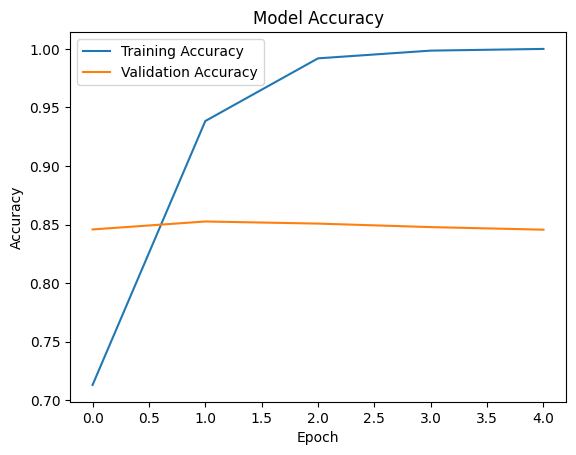

In [4]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Training Accuracy', 'Validation Accuracy'])

plt.show()